# Cotton Crop Disease Classification — Training Notebook

Trains two models on the Cotton Disease dataset (3 classes: `diseased cotton leaf`, `diseased cotton plant`, `fresh cotton leaf`):

1. A simple CNN trained from scratch
2. A VGG16 transfer-learning model

Both are saved as `.h5` files that the Flask app (`app.py`) loads for inference.

**Before running:** place this notebook in a folder that also contains a `datasets/Cotton Disease/` folder with `train/`, `val/`, `test/` subfolders (one folder per class, as in the original dataset). Works in Jupyter, VSCode, or Google Colab (recommended if you don't have a GPU locally — Colab gives you a free one under Runtime > Change runtime type > GPU).

In [1]:
# If running in Colab, uncomment to mount Drive and adjust DATA_DIR below
# from google.colab import drive
# drive.mount('/content/drive')

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: []


In [2]:
import os

DATA_DIR = '/Users/hani/Downloads/cotton-app/datasets/Cotton Disease'

TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "val")
TEST_DIR  = os.path.join(DATA_DIR, "test")

# Get only directories (ignore .DS_Store and other files)
CLASS_NAMES = sorted([
    folder for folder in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, folder))
])

print("Classes found:", CLASS_NAMES)
print("Number of classes:", len(CLASS_NAMES))

assert len(CLASS_NAMES) == 3, \
    f"Expected 3 classes, but found {len(CLASS_NAMES)}: {CLASS_NAMES}"

Classes found: ['diseased cotton leaf', 'diseased cotton plant', 'fresh cotton leaf']
Number of classes: 3


## 1. CNN model (trained from scratch, 128x128 input)

In [3]:
CNN_IMG_SIZE = (128, 128)
BATCH_SIZE = 32

cnn_train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
).flow_from_directory(TRAIN_DIR, target_size=CNN_IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical")

cnn_val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    VAL_DIR, target_size=CNN_IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical")

cnn_test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    TEST_DIR, target_size=CNN_IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False)

# Keep track of the class index -> name mapping the generator assigns
print(cnn_train_gen.class_indices)

Found 1530 images belonging to 3 classes.
Found 187 images belonging to 3 classes.
Found 79 images belonging to 3 classes.
{'diseased cotton leaf': 0, 'diseased cotton plant': 1, 'fresh cotton leaf': 2}


In [4]:
cnn_model = models.Sequential([
    layers.Input(shape=(*CNN_IMG_SIZE, 3)),
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(3, activation="softmax"),
])

cnn_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,147 (430.26 KB)

 Trainable params: 110,147 (430.26 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
cnn_history = cnn_model.fit(
    cnn_train_gen,
    validation_data=cnn_val_gen,
    epochs=20
)

Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - accuracy: 0.5712 - loss: 0.9522 - val_accuracy: 0.4866 - val_loss: 1.1374
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step - accuracy: 0.6268 - loss: 0.8855 - val_accuracy: 0.5668 - val_loss: 0.9425
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 144ms/step - accuracy: 0.6588 - loss: 0.8241 - val_accuracy: 0.5989 - val_loss: 0.8960
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 147ms/step - accuracy: 0.6843 - loss: 0.7872 - val_accuracy: 0.5668 - val_loss: 0.9119
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 151ms/step - accuracy: 0.7163 - loss: 0.7073 - val_accuracy: 0.5722 - val_loss: 0.8826
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 155ms/step - accuracy: 0.7458 - loss: 0.6184 - val_accuracy: 0.5829 - val_loss: 0.8600
Epoch 7/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 157ms/step - accuracy: 0.7719 - loss: 0.5423 - val_accuracy: 0.6631 - val_loss: 0.6941
Epoch 8/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 160ms/step - accuracy: 0.7843 - loss: 0.5438 - val_accuracy: 0.

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 205ms/step - accuracy: 0.7848 - loss: 0.5697
CNN test accuracy: 0.7848101258277893


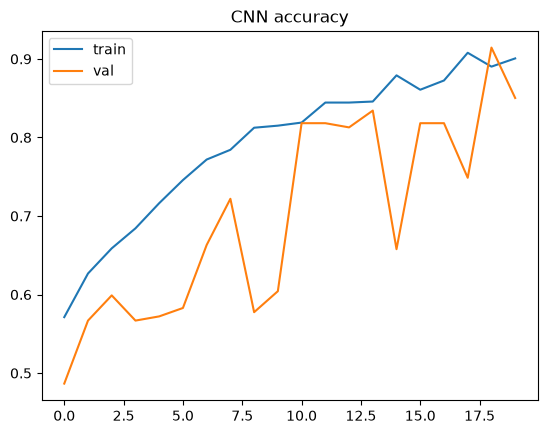

In [6]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(cnn_test_gen)
print("CNN test accuracy:", cnn_test_acc)

plt.plot(cnn_history.history["accuracy"], label="train")
plt.plot(cnn_history.history["val_accuracy"], label="val")
plt.legend(); plt.title("CNN accuracy"); plt.show()

In [7]:
cnn_model.save("model_cnn.h5")
print("Saved model_cnn.h5")

Saved model_cnn.h5


## 2. VGG16 transfer-learning model (224x224 input)

In [8]:
VGG_IMG_SIZE = (224, 224)

vgg_train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
).flow_from_directory(TRAIN_DIR, target_size=VGG_IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical")

vgg_val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    VAL_DIR, target_size=VGG_IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical")

vgg_test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    TEST_DIR, target_size=VGG_IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False)

print(vgg_train_gen.class_indices)

Found 1530 images belonging to 3 classes.
Found 187 images belonging to 3 classes.
Found 79 images belonging to 3 classes.
{'diseased cotton leaf': 0, 'diseased cotton plant': 1, 'fresh cotton leaf': 2}


In [9]:
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(*VGG_IMG_SIZE, 3))
base_model.trainable = False  # freeze pretrained convolutional base

vgg_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(3, activation="softmax"),
])

vgg_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
vgg_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,739 (56.38 MB)

 Trainable params: 66,051 (258.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [10]:
vgg_history = vgg_model.fit(
    vgg_train_gen,
    validation_data=vgg_val_gen,
    epochs=10
)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 210s 4s/step - accuracy: 0.7065 - loss: 0.7363 - val_accuracy: 0.8342 - val_loss: 0.5286
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 240s 5s/step - accuracy: 0.8601 - loss: 0.4087 - val_accuracy: 0.9251 - val_loss: 0.3296
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 226s 5s/step - accuracy: 0.9098 - loss: 0.2963 - val_accuracy: 0.9358 - val_loss: 0.2429
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 216s 5s/step - accuracy: 0.9118 - loss: 0.2435 - val_accuracy: 0.9465 - val_loss: 0.1977
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 229s 5s/step - accuracy: 0.9346 - loss: 0.2058 - val_accuracy: 0.9465 - val_loss: 0.1791
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 213s 4s/step - accuracy: 0.9333 - loss: 0.1882 - val_accuracy: 0.9412 - val_loss: 0.1600
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 227s 5s/step - accuracy: 0.9464 - loss: 0.1674 - val_accuracy: 0.9412 - val_loss: 0.1479
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 234s 5s/step - accuracy: 0.9484 - loss: 0.1606 - val_accuracy: 0.9626 - v

3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.9367 - loss: 0.1314
VGG16 test accuracy: 0.9367088675498962


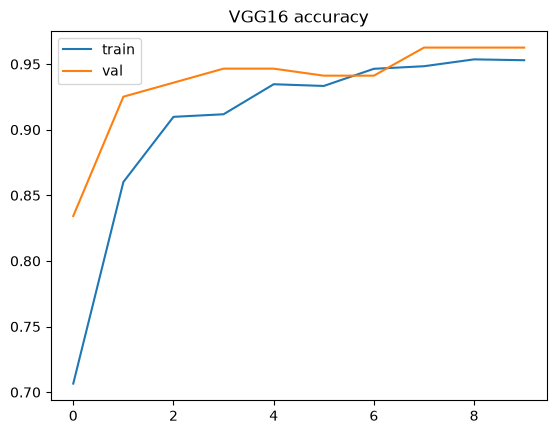

In [11]:
vgg_test_loss, vgg_test_acc = vgg_model.evaluate(vgg_test_gen)
print("VGG16 test accuracy:", vgg_test_acc)

plt.plot(vgg_history.history["accuracy"], label="train")
plt.plot(vgg_history.history["val_accuracy"], label="val")
plt.legend(); plt.title("VGG16 accuracy"); plt.show()

In [12]:
vgg_model.save("model_vgg16.h5")
print("Saved model_vgg16.h5")

Saved model_vgg16.h5


## Next step

Copy `model_cnn.h5` and `model_vgg16.h5` into the Flask app folder (same folder as `app.py`), then run the app locally to test before deploying. See `README.md` in the project folder for the full deployment walkthrough.